In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors

# 1. The Mandelbrot Set - Visualization

## What is it?
The Mandelbrot Set is a collection of points in the complex plane – a two-dimensional coordinate system where the x-axis represents real numbers and the y-axis represents imaginary numbers. Each point $c$ in this plane is simply a coordinate, like $(x, y)$ on a map.


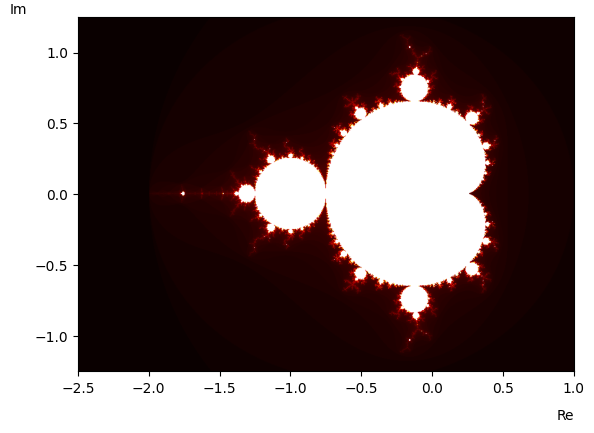

In [28]:
plt.imshow(result_array_2d, origin='lower', extent=[re_min, re_max, im_min, im_max], cmap='hot', norm=colors.PowerNorm(gamma=0.8))
plt.xlabel("Re", labelpad=10, loc='right')
plt.ylabel("Im", rotation=0, labelpad=5, loc='top')
plt.show()

## The simple rule
For every point $c$, we apply one simple rule, over and over again:
$$z_{n+1} = z_n^2 + c, \quad z_0 = 0$$
This is called **recursive sequence** – feeding the output of a calculation back as the next input.

**Example:** Take the point $c = 0.5 + 0.5i$:

| Step | z | absolute value |
|------|---|----------------|
| 0 | 0 | 0 |
| 1 | 0.5 + 0.5i | 0.71 |
| 2 | 0.5 + 1.0i | 1.12 |
| 3 | -0.25 + 1.5i | 1.52 |
| 4 | -1.69 + 0.75i | 2.07 |


The value $|z_n|$ grows – this point **escapes to infinity** and does **not** belong to the Mandelbrot Set.

## What does the color mean?
- Points that **never escape** → white (they belong to the set)
- Points that **escape quickly** → dark colors
- Points that **escape slowly** → bright colors

The fascinating boundary between escaping and non-escaping points creates the infinitely complex fractal structure visible in the image.

## Parameters
The following parameters control the visualization. Adjust `width` and `height` for higher resolution, `re_min/re_max` and `im_min/im_max` to depict a specific region, and `max_iter` to increase detail at the boundary – higher values reveal finer structure but increase computation time.

In [18]:
#Define resolution of plot
width, height = 800, 600
#Define axis of plot
re_min, re_max, im_min, im_max= -2.5, 1, -1.25, 1.25
#Define maximum number of iterations
max_iter=300

## Creating the complex plane
To evaluate every pixel, we map the image grid onto the complex plane. Each pixel $(x, y)$ corresponds to a complex number $c = re + i \cdot im$. The function `create_c_plane` returns a flat list of all these points, evenly distributed over the specified region.


In [4]:
def create_c_plane (re_min=-2.5, re_max=1, im_min=-1.25, im_max=1.25, width=width, height=height):
    c_plane_re = np.linspace(re_min,re_max,width) # np.linspace generates an array of evenly spaced numbers over a specified interval
    c_plane_im = np.linspace(im_min,im_max,height)
    c_plane=[]
    for im in c_plane_im: # nested for loop to iterate over each point in x and y direction, and add each point to a list c_plane
        for re in c_plane_re:
            c_plane.append(re + 1j*im)
    return c_plane

## Iterating the $z$-function
The function `iterate_z` applies the rule $z_{n+1} = z_n^2 + c$ repeatedly for a single point `c`. It counts how many iterations it takes until $|z| > 2$. This is the point at which the sequence is guaranteed to diverge to infinity. If the sequence never escapes within `max_iter` steps, the point belongs to the Mandelbrot Set and `max_iter` is returned.

**Input:** a single complex number `c`, maximum number of iterations `max_iter`
**Output:** number of iterations until escape, or `max_iter` if the point never escapes


In [ ]:
def iterate_z(c, max_iter=max_iter):
    z=0
    num_iter=0
    while abs(z) < 2 and num_iter < max_iter:
        z = z**2 + c 
        num_iter +=1
    return(num_iter)

## Computing the Mandelbrot Set
The function `compute_mandelbrot` applies `iterate_z` to every point in the complex plane using a list comprehension. The result is a flat list of iteration counts (one value per pixel), which is then reshaped into a 2D array matching the image dimensions `(height, width)`.

In [ ]:
def compute_mandelbrot(c_plane):
    iteration_array= [iterate_z(c) for c in c_plane]
    return iteration_array



## Running the computation
We call the functions defined above to generate the final 2D array. First the complex plane is created, then the iteration count is computed for every point, converted to a numpy array and reshaped into a 2D grid matching the image dimensions `(height, width)`.

In [ ]:
c_plane=create_c_plane()
iteration_array = compute_mandelbrot(c_plane)
result_array_1d= np.array(iteration_array)
result_array_2d= result_array_1d.reshape(height,width)

##  Visualization - Hawk tuah, Plot that thang!!!
We use `plt.imshow` to render the 2D array as an image. Each pixel represents one point in the complex plane, colored by its iteration count. 

- `origin='lower'` places the coordinate origin at the bottom left
- `extent` maps pixel coordinates to the actual complex plane coordinates
- `cmap='inferno'` defines the color scheme – black for points inside the set, bright colors for fast-escaping points
- `norm=LogNorm()` applies a logarithmic color scaling, which spreads the color gradient more evenly across the boundary region

In [ ]:
plt.imshow(result_array_2d, origin='lower', extent=[re_min, re_max, im_min, im_max], cmap='inferno', norm=colors.LogNorm())
plt.xlabel("Re", labelpad=10, loc='right')
plt.ylabel("Im", rotation=0, labelpad=5, loc='top')
plt.show()